In [69]:
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd

In [70]:
# get the data of olympics athletics
df_bios = pd.read_csv("../data/bios.csv")

In [71]:
# calculate age

df_bios["born_date"] = pd.to_datetime(df_bios["born_date"])
df_bios["died_date"] = pd.to_datetime(df_bios["died_date"])

df_bios["age"] = df_bios.died_date.dt.year - df_bios.born_date.dt.year


In [72]:
# filter out NaN values

df_bios_filtered = df_bios[df_bios['height_cm'].notna() & df_bios
['weight_kg'].notna() & df_bios["age"].notna()]

df_bios_filtered[["name", "height_cm","weight_kg", "age", "born_date", "died_date"]].head()

,name,height_cm,weight_kg,age,born_date,died_date
2,Jean Borotra,183.0,76.0,96.0,1898-08-13,1994-07-17
3,Jacques Brugnon,168.0,64.0,83.0,1895-05-11,1978-03-20
107,Anders Nielsen,173.0,70.0,43.0,1967-02-24,2010-07-29
258,Tonny Maringgi,167.0,65.0,60.0,1959-06-10,2019-09-15
291,Maureen Adams,169.0,68.0,80.0,1937-08-27,2017-12-15


In [73]:
y_df_bios_height = df_bios_filtered.groupby("age")["height_cm"].mean().reset_index()

y_df_bios_weight = df_bios_filtered.groupby("age")["weight_kg"].mean().reset_index()

x_df_bios_age = df_bios_filtered.groupby("age")


print(x_df_bios_age)

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71
 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87]


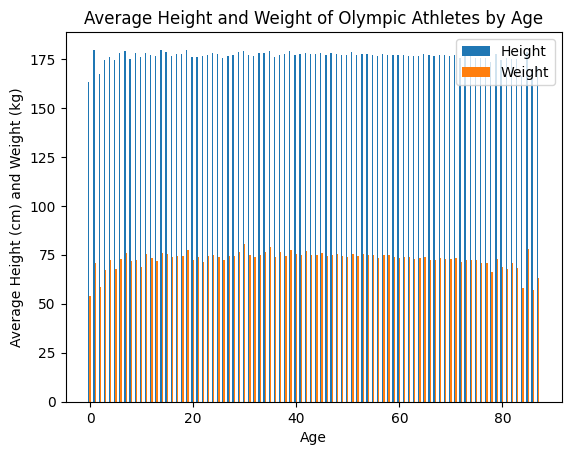

In [74]:
# plotting age vs height and weight

x_ages_indexes = np.arange(len(x_df_bios_age))
print(x_ages_indexes)
width= 0.25

plt.bar(x_ages_indexes-width, y_df_bios_height["height_cm"], label="Height", width=width)
plt.bar(x_ages_indexes,y_df_bios_weight["weight_kg"], label="Weight", width=
        width)
plt.xlabel("Age")
plt.ylabel("Average Height (cm) and Weight (kg)")
# plt.xticks(ticks=x_ages_indexes, labels=x_df_bios_age['age'])
plt.title("Average Height and Weight of Olympic Athletes by Age")

# plt.grid()
plt.legend()
plt.show()